# Part 3: NLP and Sequence Modeling Mini Project

**Dataset:** Customer Support Text Classification
**Task:** Multi-class sentiment classification — positive, neutral, negative
**Target Column:** `sentiment_label`

## Task 1: Dataset Understanding

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, os
import warnings
warnings.filterwarnings('ignore')

# load data
df = pd.read_csv('customer_support_text_classification.csv')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (1500, 6)
Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']


,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Avg word count: 12.72


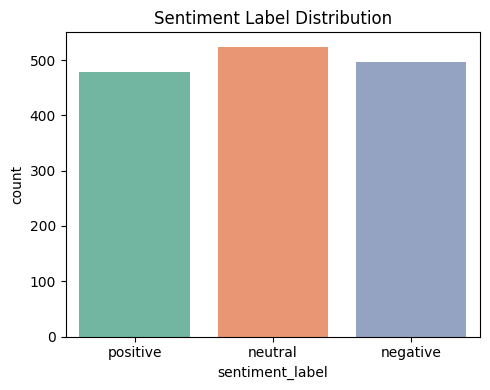

In [13]:
# target label distribution
print(df['sentiment_label'].value_counts())
print('\nAvg word count:', df['word_count'].mean().round(2))

plt.figure(figsize=(5,4))
sns.countplot(x='sentiment_label', data=df, order=['positive','neutral','negative'], palette='Set2')
plt.title('Sentiment Label Distribution')
plt.tight_layout()
plt.show()

## Task 2: Text Preprocessing

In [14]:
# text cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)   # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['customer_message'].apply(clean_text)
print('Missing values:', df[['customer_message','sentiment_label']].isnull().sum().to_dict())
df[['customer_message','clean_message']].head(3)

Missing values: {'customer_message': 0, 'sentiment_label': 0}


,customer_message,clean_message
0,I need information about the payment process. ...,i need information about the payment process m...
1,I need information about the payment process.,i need information about the payment process
2,The refund process was fast and convenient. I ...,the refund process was fast and convenient i a...


## Task 3: Text Vectorization (TF-IDF)

In [15]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment_label'])
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

X = df['clean_message']
y = df['label']

# splitting data
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)
print('TF-IDF shape:', X_train_tfidf.shape)

# Why vectorize? Models need numbers not text. TF-IDF converts each doc
# to a vector where each value reflects word importance (frequency vs rarity).

Label mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
TF-IDF shape: (1200, 570)


## Task 4: Baseline Model — Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# baseline
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

lr_acc = (y_pred_lr == y_test).mean()
print(f'Logistic Regression Accuracy: {lr_acc:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Logistic Regression Accuracy: 1.0000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



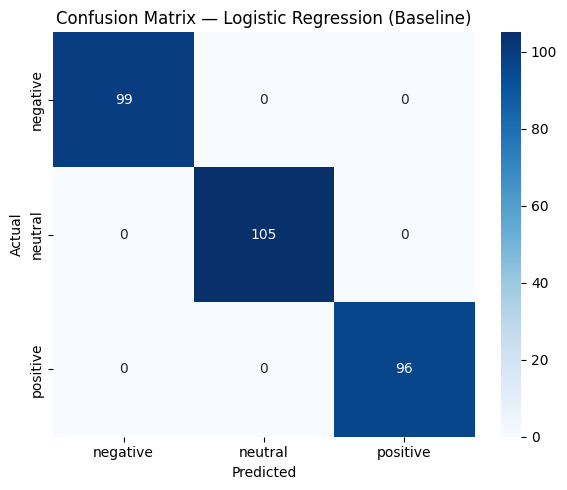

In [17]:
os.makedirs('results', exist_ok=True)

cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Logistic Regression (Baseline)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/model_evaluation.png', dpi=150)
plt.show()

## Task 5: Sequence Model — LSTM

In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

VOCAB_SIZE = 10000
MAX_LEN = 50
EMBED_DIM = 64
NUM_CLASSES = len(le.classes_)

# tokenize
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=MAX_LEN)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test_text),  maxlen=MAX_LEN)

# one-hot encode labels
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)
print('Sequence shape:', X_train_seq.shape)

Sequence shape: (1200, 50)


In [19]:
tf.random.set_seed(42)

# LSTM architecture
# Input sequence -> Embedding -> LSTM -> Dense -> Softmax
lstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),  # embedding layer
    LSTM(64, return_sequences=False),                         # recurrent layer
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')                  # output
])

lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# training
history = lstm_model.fit(X_train_seq, y_train_oh, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.6463 - loss: 0.9720 - val_accuracy: 0.9500 - val_loss: 0.6128
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.9481 - loss: 0.3004 - val_accuracy: 1.0000 - val_loss: 0.0398
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9981 - loss: 0.0188 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 8.2248e-04
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 4.4331e-04
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 1.0000 - loss: 8.3223e-04 - val_accuracy: 1.0000 - val_loss: 2.9136e-04
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 1.0000 - loss: 6.5218e-04 - val_accuracy: 1.0000 - val_loss: 2.0472e-04
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 1.0000 - loss: 5.3959e

In [21]:
# evaluate
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_seq, y_test_oh, verbose=0)
print(f'LSTM Test Accuracy: {lstm_acc:.4f} | Loss: {lstm_loss:.4f}')

# save sample predictions
y_pred_lstm = np.argmax(lstm_model.predict(X_test_seq), axis=1)
sample = pd.DataFrame({'text': list(X_test_text[:10]), 'true': le.inverse_transform(y_test[:10]), 'predicted': le.inverse_transform(y_pred_lstm[:10])})
sample.to_csv('results/sample_predictions.txt', index=False)
print('Saved sample predictions')
sample

LSTM Test Accuracy: 1.0000 | Loss: 0.0002
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
Saved sample predictions


,text,true,predicted
0,i like the new payment and it is easy to use m...,positive,positive
1,great service and clear communication from the...,positive,positive
2,my refund is still pending and this experience...,negative,negative
3,the app crashes whenever i try to use analytics,negative,negative
4,the response from the team was helpful and pro...,positive,positive
5,can someone explain the difference between the...,neutral,neutral
6,i like the new video call and it is easy to use,positive,positive
7,i like the new report download and it is easy ...,positive,positive
8,can someone explain the difference between the...,neutral,neutral
9,i want to understand the warranty terms for th...,neutral,neutral


In [22]:
# model comparison
comparison_df = pd.DataFrame([
    {'Model':'Logistic Regression (TF-IDF)','Test Accuracy':round(lr_acc,4),'Notes':'Baseline, no word order'},
    {'Model':'LSTM (Embedding)','Test Accuracy':round(lstm_acc,4),'Notes':'Sequence-aware model'}
])
comparison_df.to_csv('results/model_evaluation.csv', index=False)
print('Saved to results/model_evaluation.csv')
comparison_df

Saved to results/model_evaluation.csv


,Model,Test Accuracy,Notes
0,Logistic Regression (TF-IDF),1.0,"Baseline, no word order"
1,LSTM (Embedding),1.0,Sequence-aware model


## Task 6: Attention and Transformer Reflection

**Why do RNNs struggle with long-term dependencies?**  
RNNs process sequences step-by-step, passing a hidden state. Over long sequences, gradients vanish during backpropagation — early words get effectively forgotten by the time the model reaches the end.

**How do LSTMs help with memory?**  
LSTMs have a cell state and three gates (forget, input, output). The forget gate decides what to drop, the input gate decides what to store, and the output gate decides what to pass forward. This allows them to retain relevant information over much longer sequences.

**What does attention solve in sequence tasks?**  
Attention lets the model look back at all previous positions and decide which are most relevant for the current step — instead of relying on a single compressed hidden state. This dramatically improves performance on long texts.

**Why are transformers important in modern NLP and Generative AI?**  
Transformers (BERT, GPT) replace recurrence entirely with self-attention. All tokens are processed in parallel, which is much faster to train and scales to huge datasets. Pre-trained transformers can be fine-tuned for almost any NLP task with very few examples, making them the foundation of modern Generative AI.